In [1]:
# Standard library
import json
import warnings

# Third-party libraries
import joblib
import numpy as np
import pandas as pd
import requests

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import seaborn as sns

# Stats / Time Series
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

# Preprocessing / Pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Models
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
)
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)

# Gradient boosting frameworks
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Model inspection / evaluation
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Advanced Business Analytics — Main Report

**Course:** Advanced Business Analytics  
**Institution:** Technical University of Denmark (DTU)  
**Group:** XXX  
**Authors:** Simone Egede von Mehren s190739, XXX, XXX, XXX 

---

## Abstract

*(Write 4–6 sentences summarising the research question, data, methods, and key finding once the analysis is complete.)*

## Table of Contents

1. [Research Question](#1-research-question)
2. [Data](#2-data)
3. [Feature Engineering](#3-feature-engineering)
4. [Modelling](#4-modelling)
5. [Explainability and Endogeneity](#5-explainability-and-endogeneity)
6. [Results](#6-results)
7. [Discussion](#7-discussion)
8. [Conclusion](#8-conclusion)
9. [Appendix](#9-appendix)

---
## 1. Research Question

*(State the research question and motivation. What are we trying to predict and why does it matter?)*

---
## 2. Data

We use three main data sources, each covering the period 14 November 2025 – 10 April 2026 (148 days):

| Source | Description |
|---|---|
| Truth Social posts | 1,900+ posts scraped from @realDonaldTrump |
| News articles | XXX |
| Macro indicators | XXX |

All sources are merged to a single daily-frequency dataset of 148 trading days (`joined_features/full_dataset.csv`). Full collection and cleaning code is provided in the [Appendix](#9-appendix).

### 2.1 Data collection

#### 2.1.1 Truth soical
We tried some differnt techniques
 - **Classic web scraping using request** : This dind't work, beacuse truth Social isn't a static HTML like wikipedia, but a post are fetcehd using javascript meaning that if you just pull the HTML using requst we will not get more than 1-2 post. 

In [2]:
html = requests.get("https://truthsocial.com/@realDonaldTrump").text
print(html[:100])

<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Typ


Then we tried to use **playwright.async_api** to automated the browser meaning that we scraped the site contiuesly while having it open and scrolling down the site. But this scraping was too heavy and was bloked by Cloudfare very quickly.

This was a bit of a shame, beacuse the feature is pretty cool where we can load page and run javascript and even make it scrool automatically.

In [3]:
'''
async def main():
    results = []

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
        await page.goto(PROFILE_URL, wait_until="domcontentloaded", timeout=120000)
        await page.wait_for_timeout(5000)

        ....

        await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
'''
None

Then we found **Truthbrush** an opensource software designed to scrape data form truth soical. 

We wanted to do some kind of automation as seen below, but we didn't have a way of fitering on the post, so we couldn't make it do more than repeadialty download the same post each 10 minutes

In [4]:
'''
#!/bin/bash

set -e

# Make sure we are updaated
sudo apt update
sudo apt install python3-pip -y
pip3 install truthbrush

while true; do
    TIMESTAMP=$(date +"%Y-%m-%d_%H-%M-%S")
    OUTPUT_FILE="realDonaldTrump_truths_${TIMESTAMP}.json"

    truthbrush statuses realDonaldTrump > "$OUTPUT_FILE"

    sleep 600

'''
None

The only option we had left is to do it in the simple way using a CLI, and letting it run until we were bloked by cloudfare. The program was able to get 4 month of data before getting blocked.

In [5]:
'''
export TRUTHSOCIAL_USERNAME="your_username"
export TRUTHSOCIAL_PASSWORD="your_password"

truthbrush statuses realDonaldTrump > realDonaldTrump_truths4.json
'''
None

#### 2.1.2 News data

We tried differnt news outlets and online API, some didn't work beacuse of the limits on free plan like News API or Gnews. Some news site didn't have and API, but we found two that did. The guardian and New york times.

This code is way too long to fit into the notebook, but it can be founud under appendix_B_news/get_data.ipynb. Essentially we call the API, check the content for mentionenins of trump, if he is mention we append to a .csv otherwise we discard it.

#### 2.1.2 Marco economic indicators

---
## 3. Feature Engineering

### 3.1 Trump post features — behavioural

Raw data consists of 3 JSON scrape files from @realDonaldTrump on Truth Social, covering 14 November 2025 – 10 April 2026. After deduplication (keeping the most recently scraped copy of each post so engagement counts are as current as possible), the dataset contains 1,939 posts across 146 posting days. Two calendar days in the period have no posts (2025-12-21 and 2025-12-29) and are retained in the daily dataset with zero-filled engagement counts.

Posts containing only images and no text are flagged separately, as they cannot contribute to NLP features. The following 11 behavioural signals are computed at daily frequency:

| Feature | Description |
|---|---|
| `post_count` | Total number of posts in the day |
| `n_image_only` | Number of posts with no text content |
| `avg_upvotes` | Mean upvote count across posts |
| `max_upvotes` | Maximum upvote count (peak engagement) |
| `total_upvotes` | Sum of upvotes — captures total daily reach |
| `avg_reblogs` | Mean reblog (reshare) count |
| `total_reblogs` | Sum of reblogs |
| `avg_replies` | Mean reply count |
| `n_quotes` | Number of posts that quote another post |
| `n_with_link` | Number of posts containing an external link |
| `avg_text_len` | Average character length of text posts |

Follower count was extracted from the raw data but found to take only two distinct levels (~11.97M and ~12.32M) reflecting the two scrape batches rather than genuine daily variation. It is therefore excluded from the feature set.
Full code is provided in **Appendix A** (`appendix_A_trump/01_trump_data.ipynb`).

### 3.2 Trump post features — NLP

#### Text preprocessing

Before any model is applied, post text is cleaned in three steps: (1) URL removal, including Truth Social's broken URL format where spaces are inserted mid-link; (2) HTML tag stripping; (3) normalisation of whitespace and removal of leading/trailing spaces.

#### Topic modelling (BERTopic)

Topic modelling is performed using BERTopic. Each post is encoded into a high-dimensional embedding using a pre-trained sentence transformer (`all-MiniLM-L6-v2`). Embeddings are reduced to 5 dimensions with UMAP and clustered with HDBSCAN. Topic labels are derived from class-based TF-IDF over the words in each cluster. A fixed random seed is used for reproducibility.

BERTopic identifies 13 topics plus an outlier class (topic -1) for posts that do not fit any coherent group. The table below lists all topics with their representative keywords and whether they are retained as predictive signals:

| Topic | Keywords | Posts | Used | Rationale |
|---|---|---|---|---|
| 0 | endorsement, state, secure, district | 267 | No | Formulaic endorsement posts — no market mechanism |
| 1 | tariffs, united states, court | 152 | **Yes** | Strongest economic signal |
| 2 | minnesota, ICE, criminals, democrats | 134 | **Yes** | Immigration — political resilience signal |
| 3 | Iran, president donald | 114 | **Yes** | Foreign policy / geopolitical risk |
| 4 | white house, ballroom, center | 69 | No | Event announcements — no interpretable signal |
| 5 | president DJT, great, fantastic | 46 | No | Generic presidential messaging |
| 6 | Epstein, fake news, New York Times | 43 | **Yes** | Media attacks — base-rallying signal |
| 7 | Venezuela, oil, Honduras | 42 | **Yes** | Energy / sanctions signal |
| 8 | state of the union, address | 31 | No | Single recurring event, no daily variance |
| 9 | Save America, voter ID | 28 | **Yes** | Election integrity signal |
| 10 | peace, Gaza, NATO | 26 | **Yes** | Geopolitical uncertainty |
| 11 | judge, court, district | 23 | **Yes** | Judicial / policy uncertainty |
| 12 | water, Mexico, storm, environmental | 21 | No | Only 21 posts — too sparse |

For each post, BERTopic returns a probability score for every topic. These are summed (not averaged) across all posts in a day to form the daily `topic_activity` signals. Summing preserves posting intensity — a day with 20 tariff posts is meaningfully different from a day with 2 — and avoids perfect multicollinearity that would arise if per-post probability vectors (which sum to 1) were averaged.

#### Sentiment analysis (VADER)

VADER (Valence Aware Dictionary and sEntiment Reasoner) is applied to each cleaned post, producing a compound sentiment score in [-1, 1]. Three daily signals are derived:

| Feature | Description |
|---|---|
| `sentiment_mean` | Mean compound score across all posts in the day |
| `sentiment_std` | Standard deviation — captures within-day tonal variation |
| `sentiment_pct_negative` | Share of posts with compound score < -0.05 |

A spot-check of extreme days confirms that the most negative and positive days tend to be single-post days where one unusually toned post dominates the average. On high-volume days, the daily score reflects an average across a full news cycle. A notable limitation is that VADER reads adversarial posts (criminal referrals, attacks on opponents) as negative regardless of political intent, which may not translate to a negative market signal.

Full code is provided in **Appendix A** (`appendix_A_trump/02_trump_nlp.ipynb`).

### 3.3 News sentiment features

*(Add description of news data source, collection method, and how daily sentiment signals are derived. Include a feature table analogous to 3.1 and 3.2.)*

Full code is provided in **Appendix B** (`appendix_B_news/`).

### 3.4 Macro features

*(Add description of FRED indicators used (CPI, Fed Funds Rate, Unemployment, Consumer Sentiment), any transformations applied (e.g. log differences, lags), and a feature table.)*

Full code is provided in **Appendix C** (`appendix_C_macro/`).

### 3.5 Loading all data

In [6]:
# First we load the data with all features joined together. 
data_path = "../joined_features/full_dataset.csv"
df = pd.read_csv(data_path)

In [7]:
# We decided that we need topics to be one-hot encoded.
topic_cols = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11'
]

max_cols = df[topic_cols].idxmax(axis=1)
df[topic_cols] = 0
for col in topic_cols:
    df.loc[max_cols == col, col] = 1

In [8]:
# We remove empty rows.
df = df[df["post_count"] != 0]
nan_count = df.isna().sum().sum()
print(f"Number of NaN values: {nan_count}")

if nan_count > 0:
    failing_cols = df.columns[df.isna().any()]
    print(f"Columns with NaN: {list(failing_cols)}")

df = df.sort_index() # Ensure time order

Number of NaN values: 1
Columns with NaN: ['avg_text_len']


In [9]:
# Then we split the data into train, validation, and test sets.
# While still maintaining the time order of the data (no shuffling).
n = len(df)

train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

---
## 4. Modelling


### 4.1 Simple model testing

Now that we have gathared some data we want try different possibilities given this data. Our project scope include trying to predict 3 types of scenarios:
 - Maro economical indicators
 - News sentiment around trump
 - Trump popularity

corresponding to 3 sets of features/predictor. We test with 3 diffent model for the simple test Linear regression, second order linear regression and ARX. But to spare you the details we are only showing 1 for each senario, but all test can be found in the appendix

**Conclustion of 3 test:**

**News sentiment** : We were not able to make a simple model that beat just taking the mean on the validation set. We expirienced high bias. We seemed to be able to explain the variance pretty good, but not capturing the trends.

**Macro economical indicators** : Since these measure are only avalible on a monthly frequency, and we only have 4 month of data. There is not way for us model any patterns. If we had more data we could have aggregated our features to a monthly frequency.

**Trump popularity (Best pick)** : We seem to be able to capture the trend on validation for all 3 target variables using a linear regression model. (Note we are not doing multi output prediction yet, but just fitting 3 distinct model). The residuals of the OLS also seems to follow a normal distribution, so we are probably not going to find super complex patterns int he data, but maybe we can imporve upon the result using simpler models like random forrest or SVM.


#### 4.1.1 Simple test - News sentiment

In [10]:
features = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2', 'topic_activity_3', 'topic_activity_4', 'topic_activity_5', 'topic_activity_6', 'topic_activity_7', 'topic_activity_8', 'topic_activity_9', 'topic_activity_10', 'topic_activity_11',
    'topic_activity_12', 'trump_sentiment_mean_x', 'trump_sentiment_std', 'trump_sentiment_pct_negative', 'cpi', 'interest_rate', 'consumer_sentiment','unemployment'
]

predictors = [
    'news_sentiment_rolling', 'news_sentiment_mean_y'
]

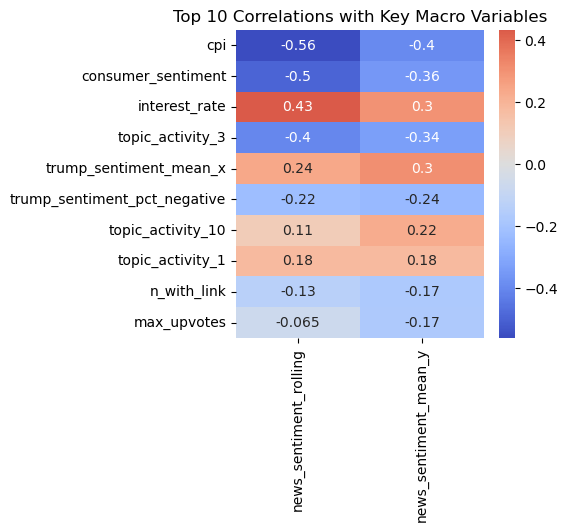

In [11]:
########## ---------- Correlation matrix ---------- ########## 
df_numeric = df.select_dtypes(include="number")
corr_matrix = df_numeric.corr()

corr_subset = corr_matrix[predictors].drop(index=predictors, errors="ignore")
top10 = corr_subset.abs().max(axis=1).sort_values(ascending=False).head(10).index
corr_subset = corr_subset.loc[top10]

plt.figure(figsize=(4, 4))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0)
plt.title("Top 10 Correlations with Key Macro Variables")
plt.show()

The chart shows that economic indicators seem to have the biggest influence on news sentiment. Higher inflation (CPI) and lower consumer confidence are linked to more negative sentiment, while higher interest rates are associated with more positive sentiment.

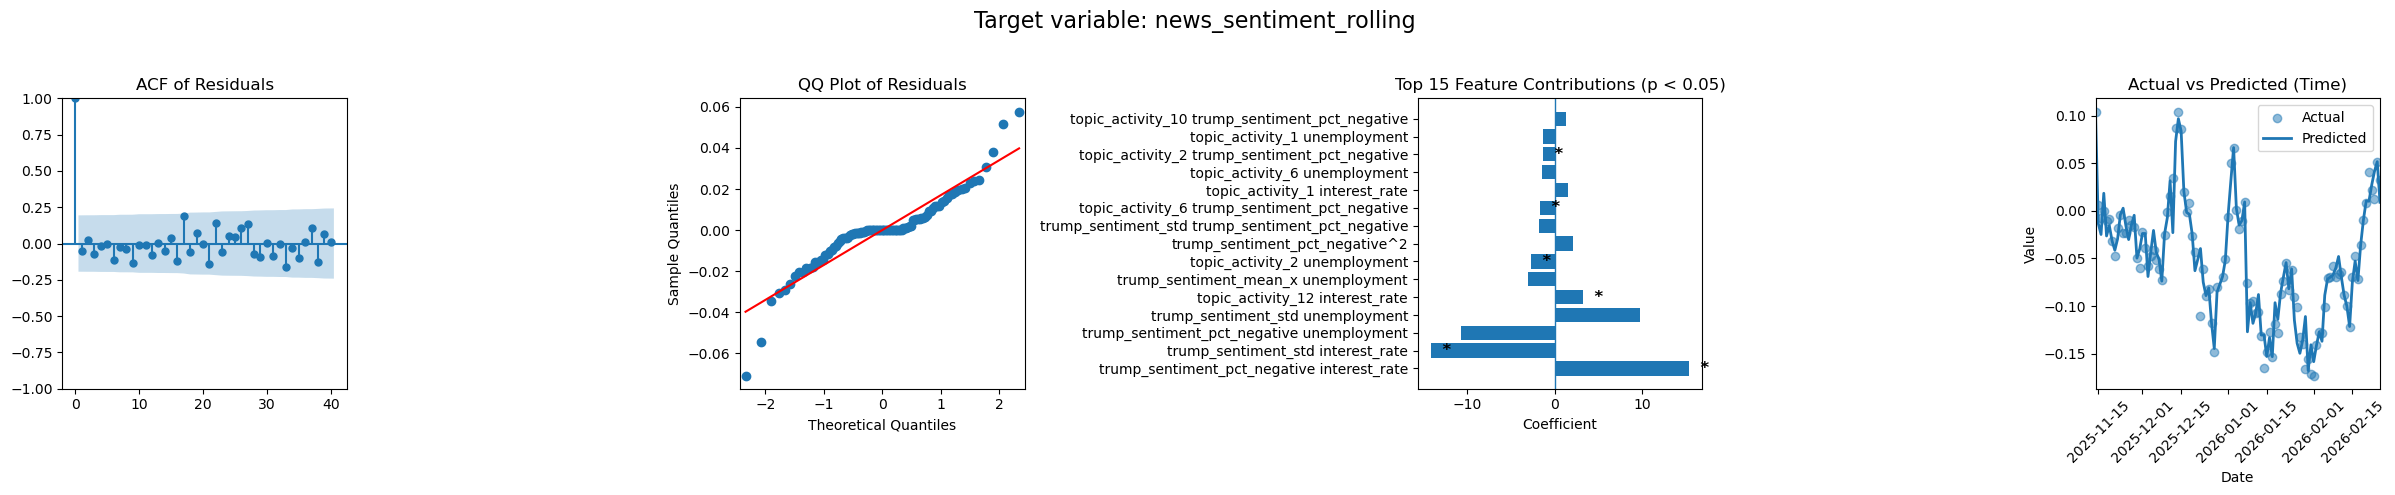

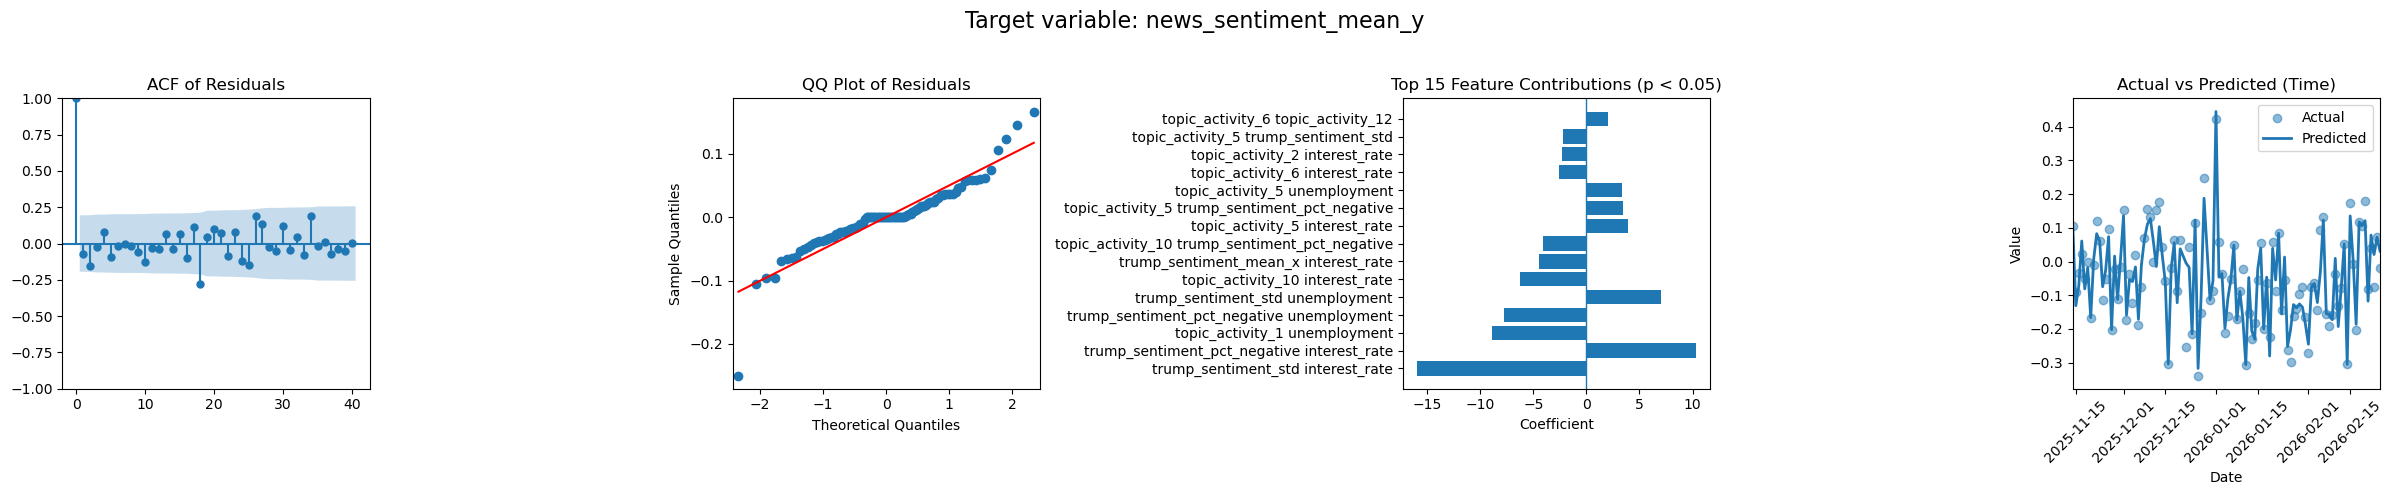

In [12]:
from appendix_D_modelling.utils_simple import train_model_ols, train_model_ols_second_order, train_model_arx, diagnose_model

for i in range(len(predictors)): 
    model_ols = train_model_ols_second_order(train, features, predictors[i])
    diagnose_model(model_ols, time_data=df["date"], title=("Target variable: " + predictors[i]))

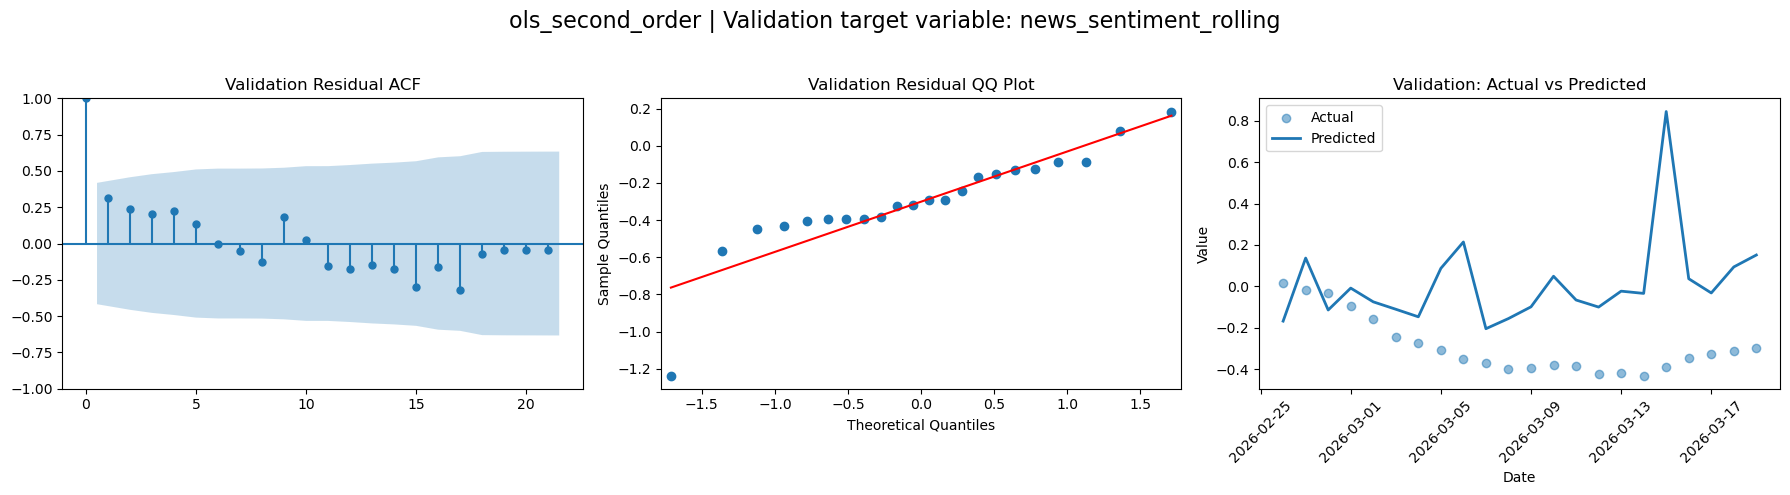

ols_second_order news_sentiment_rolling {'mse': 0.16366660748188055, 'rmse': 0.40455729814437974, 'mae': 0.3250522032821847, 'r2_validation': -7.708165121376247}


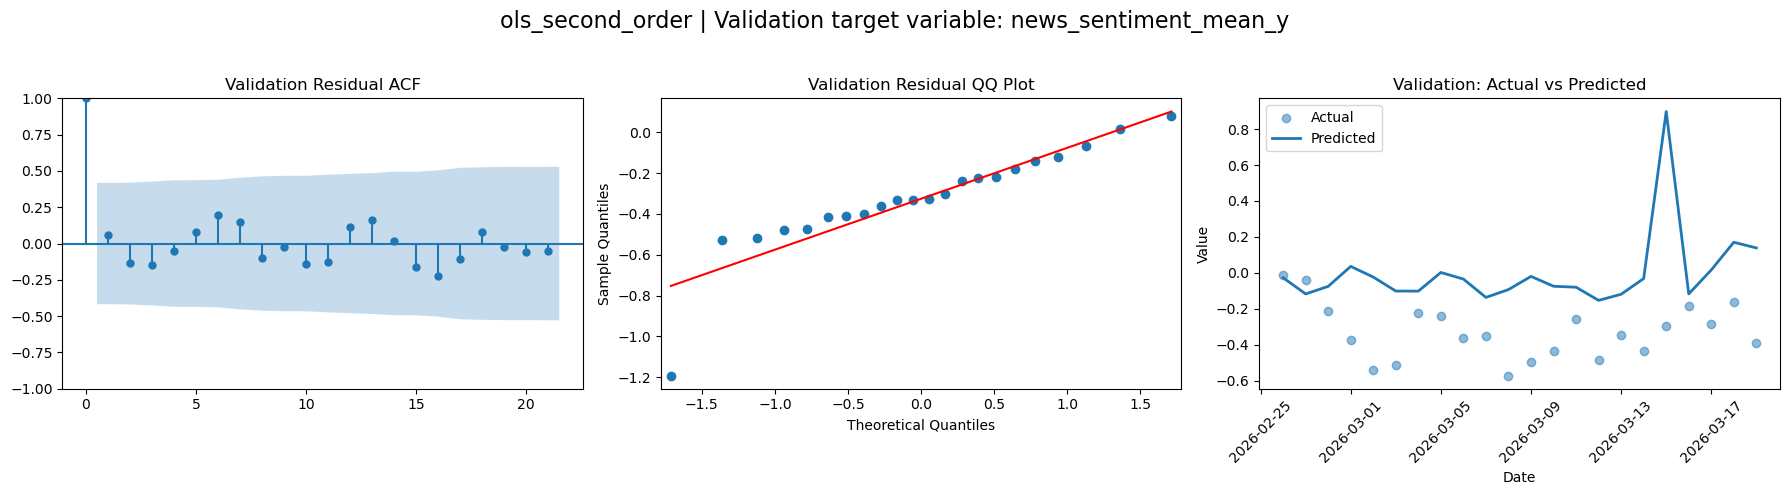

ols_second_order news_sentiment_mean_y {'mse': 0.16817092095054792, 'rmse': 0.4100864798436397, 'mae': 0.334268185489722, 'r2_validation': -6.498225892936591}


In [13]:
from appendix_D_modelling.utils_simple import diagnose_validation

models = [
    ("ols_second_order", train_model_ols_second_order)
]

for model_name, model_func in models:
    for predictor in predictors:

        fitted_model = model_func(train, features, predictor)

        val_scores = diagnose_validation(
            fitted_model,
            val_df=val,
            features=features,
            target=predictor,
            time_col="date",
            title=f"{model_name} | Validation target variable: {predictor}"
        )

        print(model_name, predictor, val_scores)

#### 4.1.2 Simple test - Macro economic indicators

In [14]:
features = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11',
    'topic_activity_12', 'trump_sentiment_mean_x', 'trump_sentiment_std',
    'trump_sentiment_pct_negative',  'news_sentiment_rolling', 'news_sentiment_mean_y',
    'cpi', 
    'interest_rate', 
    'consumer_sentiment',
    'unemployment'
]

predictors = [
    'cpi', 'interest_rate', 'consumer_sentiment', 'unemployment'
]

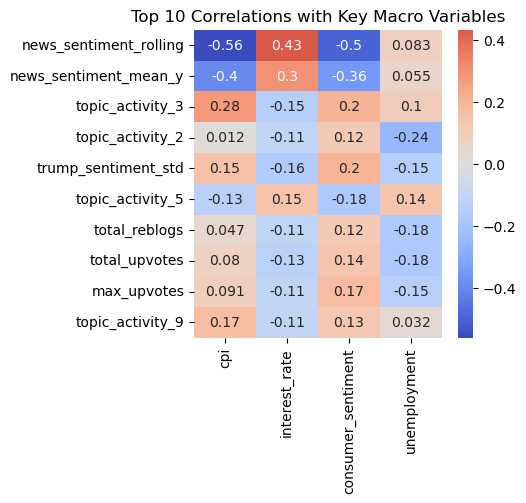

In [15]:
########## ---------- Correlation matrix ---------- ########## 
df_numeric = df.select_dtypes(include="number")
corr_matrix = df_numeric.corr()

corr_subset = corr_matrix[predictors].drop(index=predictors, errors="ignore")
top10 = corr_subset.abs().max(axis=1).sort_values(ascending=False).head(10).index
corr_subset = corr_subset.loc[top10]

plt.figure(figsize=(4, 4))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0)
plt.title("Top 10 Correlations with Key Macro Variables")
plt.show()

Inflation (CPI) and consumer sentiment show the strongest negative relationships with news sentiment, while interest rates are positively correlated, suggesting that shifts in the economic environment are reflected in how news is framed.

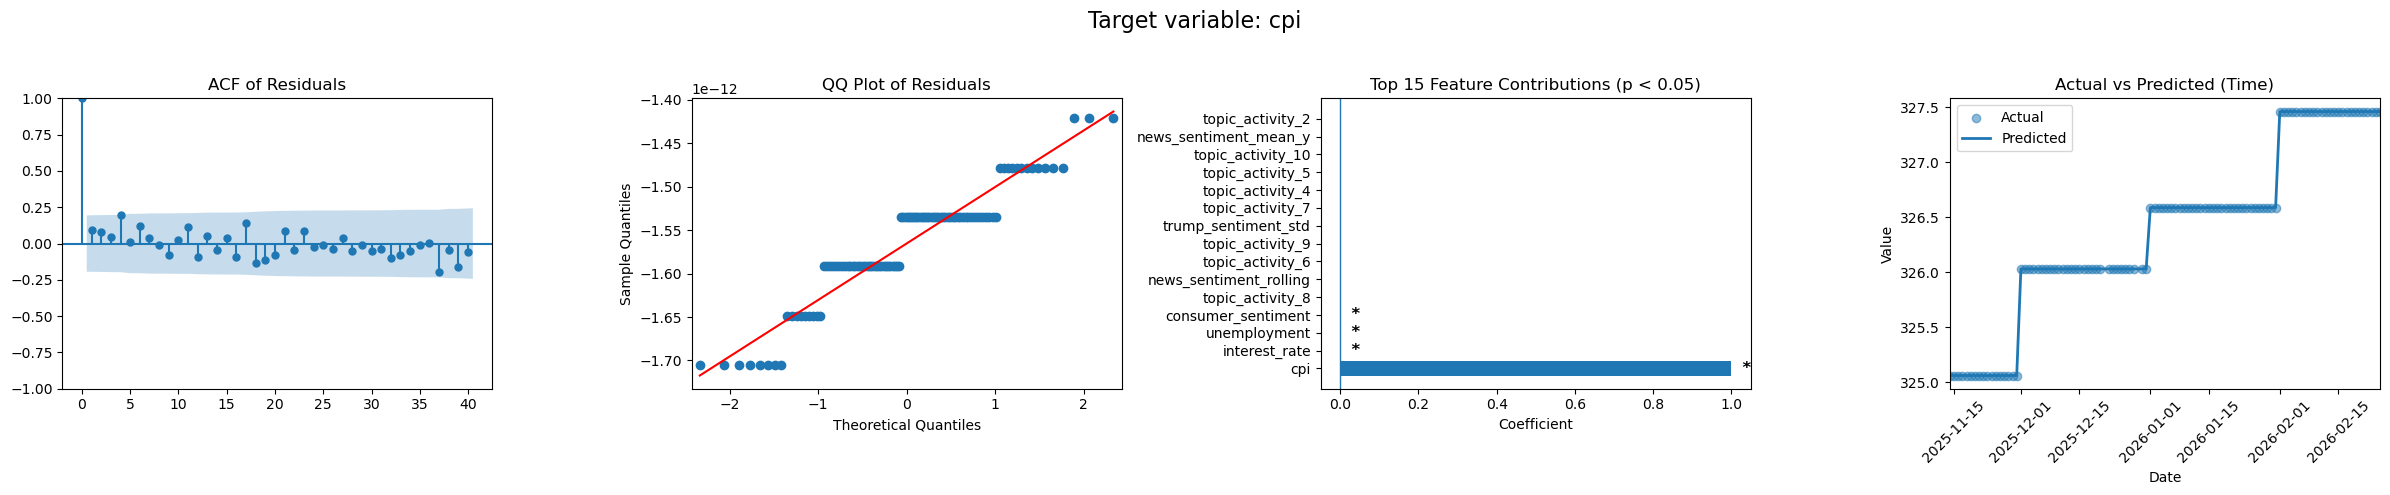

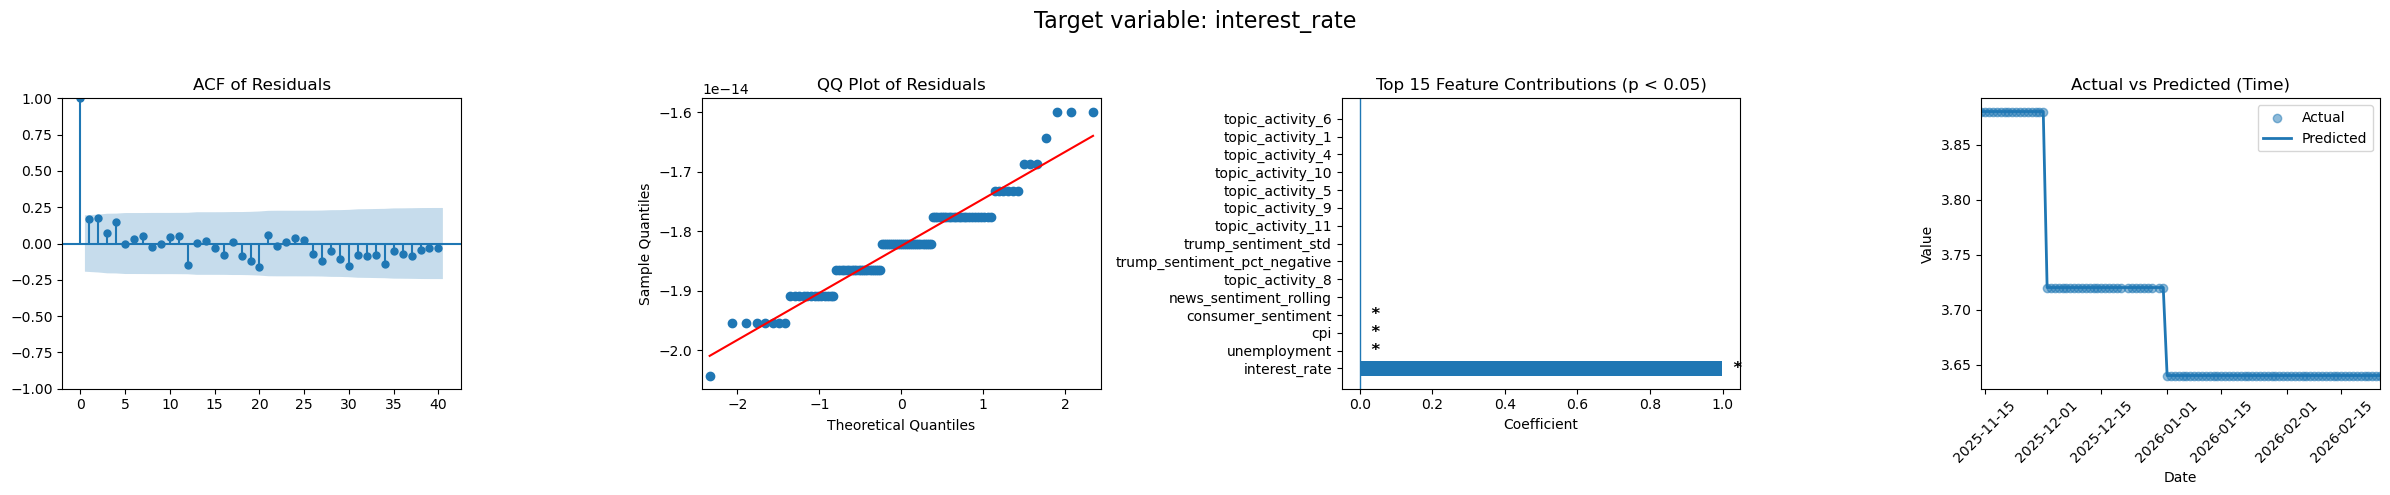

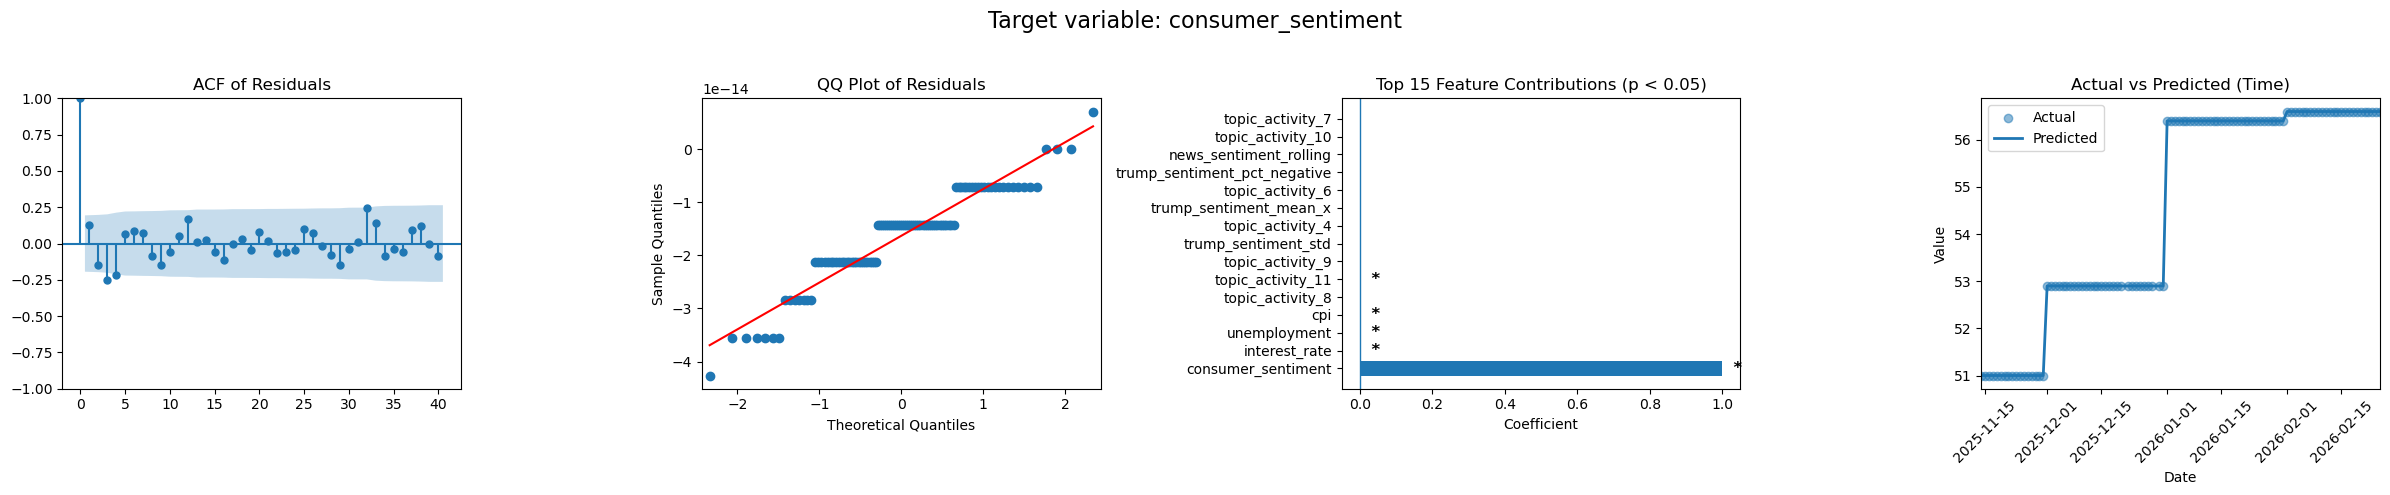

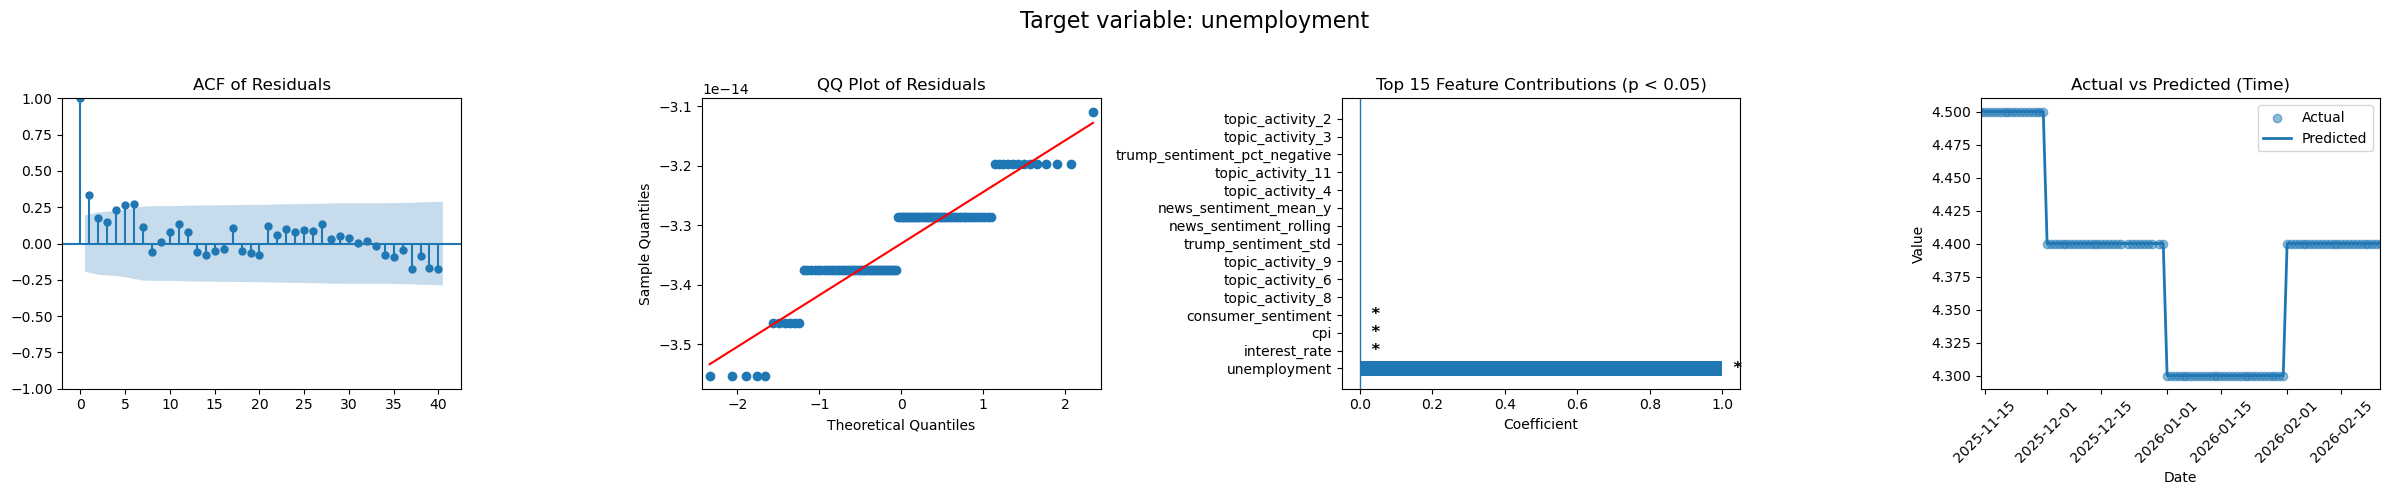

In [16]:
for i in range(len(predictors)): 
    model_ols = train_model_ols(train, features, predictors[i])
    diagnose_model(model_ols, time_data=df["date"], title=("Target variable: " + predictors[i]))

#### 4.1.3 Simple test - Trump popularity

In [17]:
features = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11',
    'topic_activity_12', 'trump_sentiment_mean_x', 'trump_sentiment_std',
    'trump_sentiment_pct_negative', 
    'cpi', 
    'interest_rate', 
    'consumer_sentiment',
    'unemployment', 'news_sentiment_rolling', 'news_sentiment_mean_y',
]

predictors = [
    'avg_reblogs', 'avg_upvotes', 'total_upvotes'
]

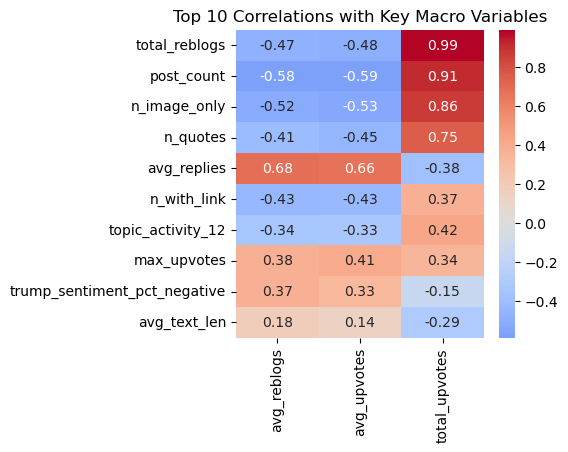

In [18]:
########## ---------- Correlation matrix ---------- ########## 
df_numeric = df.select_dtypes(include="number")
corr_matrix = df_numeric.corr()

corr_subset = corr_matrix[predictors].drop(index=predictors, errors="ignore")
top10 = corr_subset.abs().max(axis=1).sort_values(ascending=False).head(10).index
corr_subset = corr_subset.loc[top10]

plt.figure(figsize=(4, 4))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0)
plt.title("Top 10 Correlations with Key Macro Variables")
plt.show()

Although variables such as total_reblogs, post_count, and image-only post counts show strong correlations with engagement metrics (especially total upvotes), they were excluded from the predictive model because they would introduce data leakage or trivial predictions. These features are only fully known after posts have already been published and interacted with, which makes them unavailable at the time of prediction. Since the goal is to predict post popularity in advance, we focus only on features that are realistically observable beforehand, such as average reblogs, average upvotes, and sentiment-based indicators.

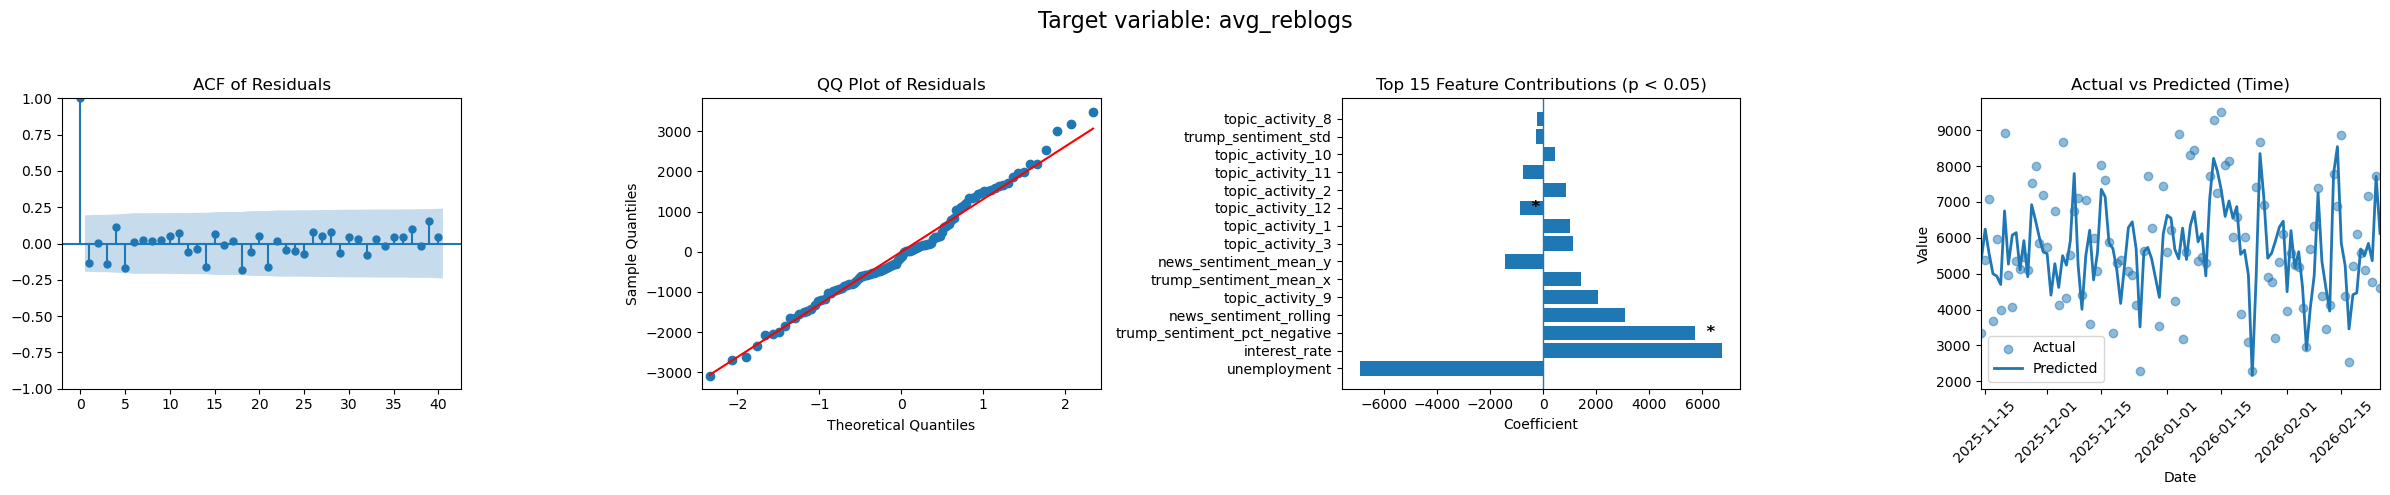

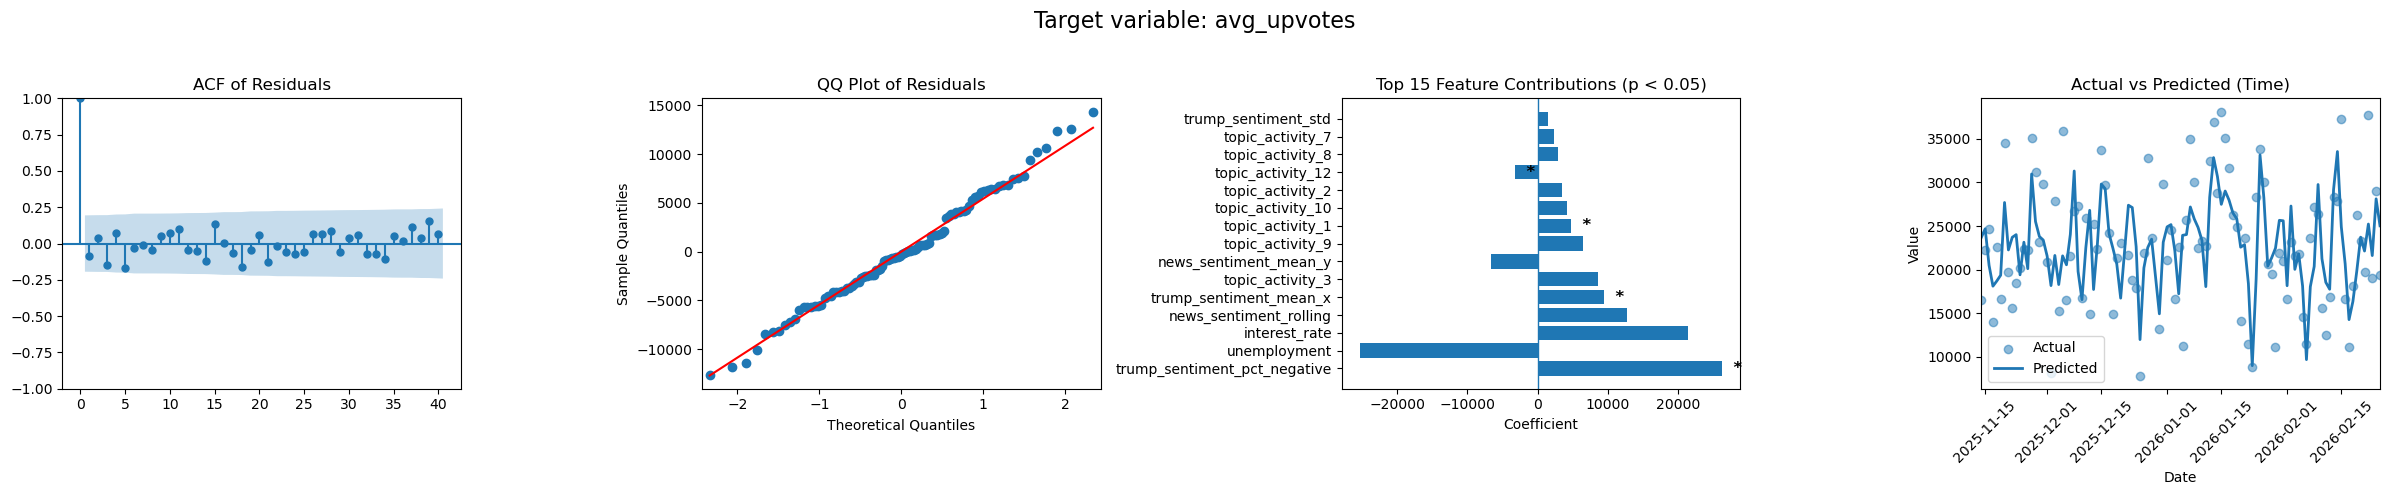

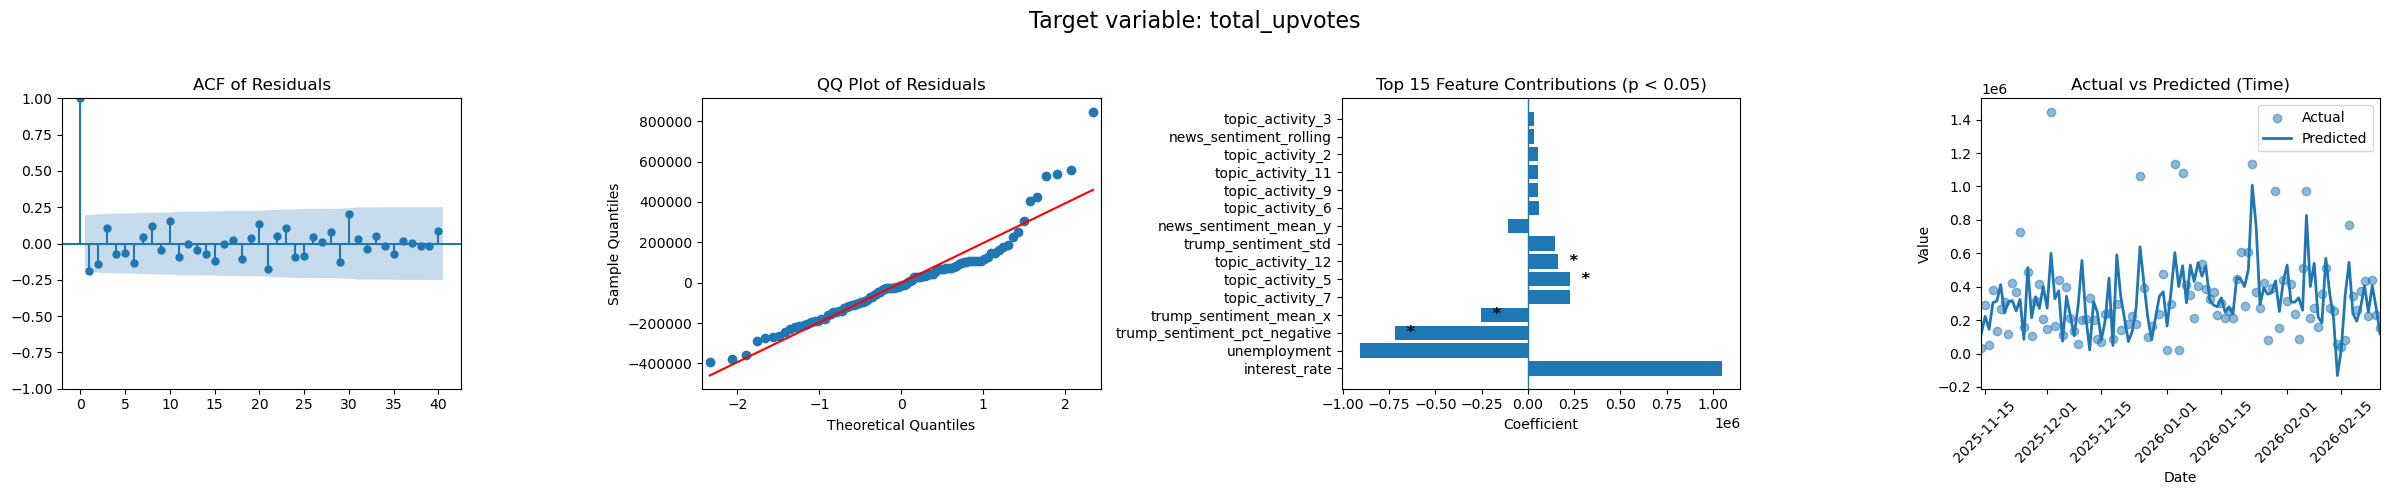

In [19]:
for i in range(len(predictors)): 
    model_ols = train_model_ols(train, features, predictors[i])
    diagnose_model(model_ols, time_data=df["date"], title=("Target variable: " + predictors[i]))

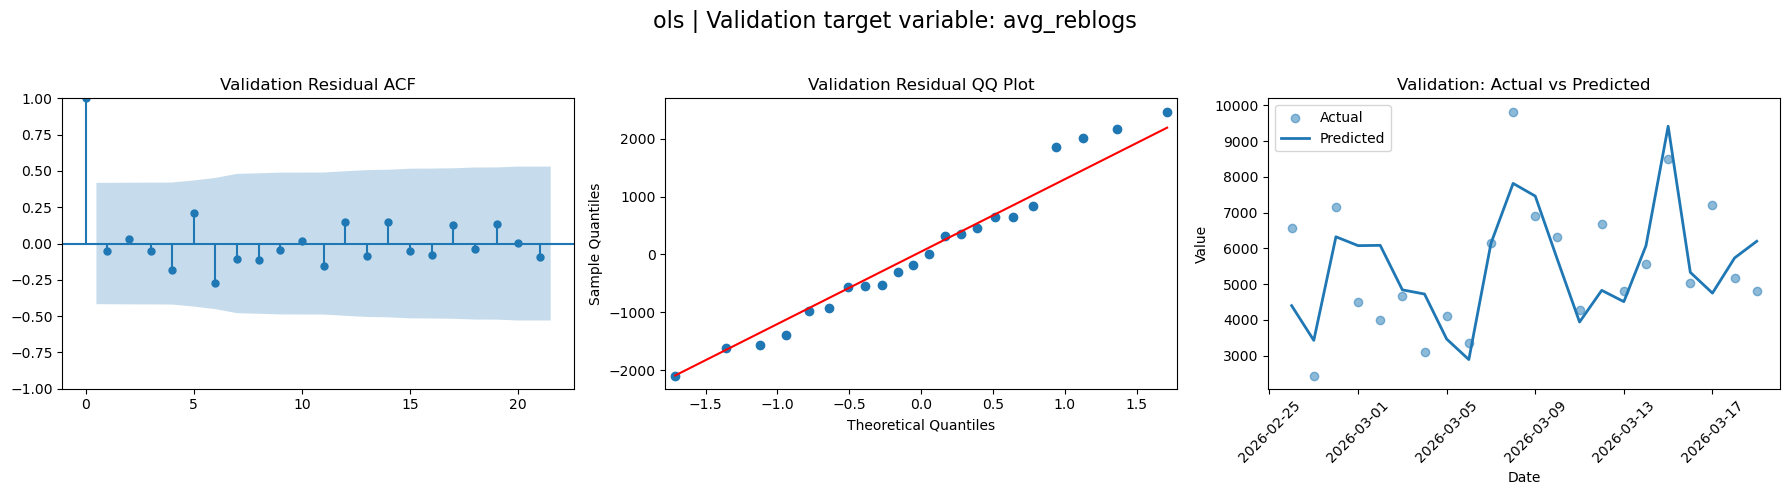

ols avg_reblogs {'mse': 1568909.103691788, 'rmse': 1252.5610179515359, 'mae': 1020.7080569348883, 'r2_validation': 0.4876981837206251}


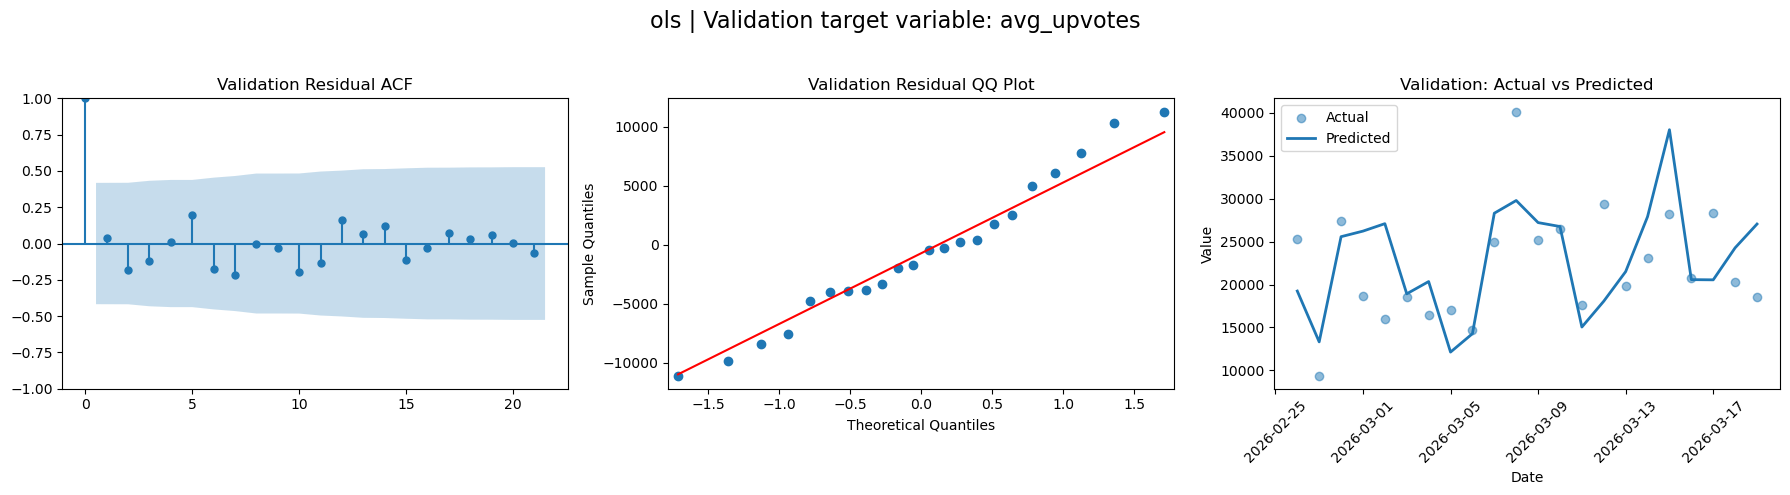

ols avg_upvotes {'mse': 36511560.95224964, 'rmse': 6042.479702262113, 'mae': 4850.779810420004, 'r2_validation': 0.11590107194030097}


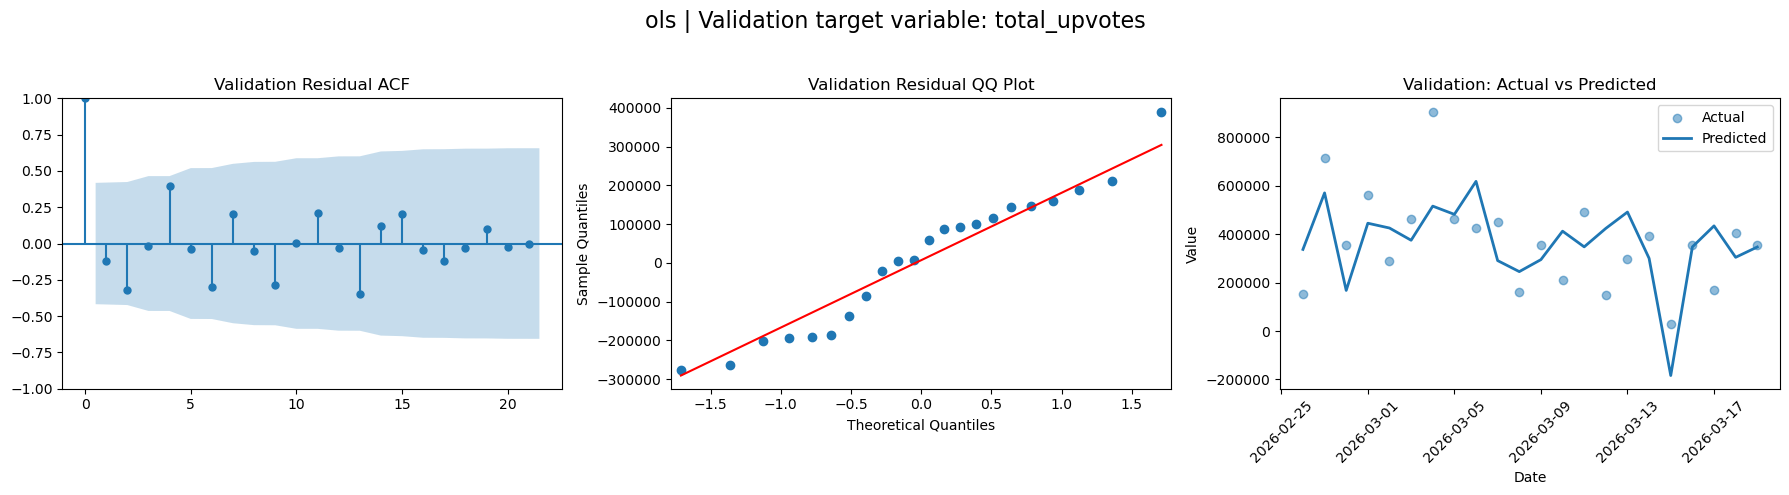

ols total_upvotes {'mse': 30284648454.45196, 'rmse': 174024.850106104, 'mae': 148407.61815801694, 'r2_validation': 0.19001827128596027}


In [20]:
from appendix_D_modelling.utils_simple import diagnose_validation

models = [
    ("ols", train_model_ols)
]

for model_name, model_func in models:
    for predictor in predictors:

        fitted_model = model_func(train, features, predictor)

        val_scores = diagnose_validation(
            fitted_model,
            val_df=val,
            features=features,
            target=predictor,
            time_col="date",
            title=f"{model_name} | Validation target variable: {predictor}"
        )

        print(model_name, predictor, val_scores)

### 4.2 Advanced model picking

#### 4.2.1 - Trying differnt models on the traning data

In [21]:
X_train, X_val, X_test = train[features], val[features], test[features]
Y_train, Y_val, Y_test = train[predictors], val[predictors], test[predictors]

We selected a set of regression models to compare. The model set includes both linear and non-linear methods to capture different types of relationships in the data. The linear models was very strong in our baseline, so we picked multipl eof these (Linear Regression, Ridge, Lasso, and Elastic Net).

In [22]:
import appendix_D_modelling.utils_ml as utils_ml

models = {
    "linear_regression": Pipeline([("scaler", StandardScaler()), ("model", MultiOutputRegressor(LinearRegression()))]),

    "ridge": Pipeline([("scaler", StandardScaler()), ("model", MultiOutputRegressor(Ridge(alpha=0.1)))]),

    "lasso": Pipeline([("scaler", StandardScaler()), ("model", MultiOutputRegressor(Lasso(alpha=0.01)))]),

    "elastic_net": Pipeline([("scaler", StandardScaler()), ("model", MultiOutputRegressor(ElasticNet(alpha=0.01, l1_ratio=0.5)))]),

    "random_forest": MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),

    "extra_trees": MultiOutputRegressor(ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)),

    "gradient_boosting": MultiOutputRegressor(GradientBoostingRegressor(n_estimators=200, random_state=42)),

    "xgboost": MultiOutputRegressor(XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        random_state=42, n_jobs=-1, objective="reg:squarederror"
    )),
    "lightgbm": MultiOutputRegressor(LGBMRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=-1,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )),

    "mlp": Pipeline([("scaler", StandardScaler()), ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64), activation="relu",
        max_iter=1000, random_state=42
    ))])
}

In [23]:
warnings.filterwarnings("ignore")
results, results_df = utils_ml.run_all_models(
    models,
    X_train,
    Y_train,
    X_val,
    Y_val
)
warnings.filterwarnings("default") 

In [24]:
df_results = pd.DataFrame(results)
df_results = df_results.drop(columns=["model"]) 
df_results = df_results.sort_values("rmse")

baseline_preds = Y_test.shift(1)

baseline_r2 = r2_score(Y_test.iloc[1:], baseline_preds.iloc[1:])

print("Baseline r2", baseline_r2)
df_results["improvement"] = df_results["r2"] - baseline_r2

print(df_results.sort_values("improvement", ascending=False))

Baseline r2 -0.45321030684875185
          model_name           rmse           mae        r2  improvement
4      random_forest  102774.062670  45939.027598  0.271179     0.724389
3        elastic_net  100341.563873  51251.269795  0.268300     0.721510
1              ridge  100500.089353  51392.240833  0.265318     0.718528
2              lasso  100536.453475  51426.356048  0.264553     0.717763
0  linear_regression  100536.442687  51426.368675  0.264539     0.717749
5        extra_trees  107923.984697  43328.333227  0.206758     0.659969
8           lightgbm  108345.435427  49932.150807  0.193113     0.646323
7            xgboost  111137.778275  45639.718750  0.133493     0.586703
6  gradient_boosting  121590.075842  50657.479617  0.013634     0.466844
9                mlp  161999.255700  81839.596561 -4.777032    -4.323821


Random Forest achieved the highest R^2 score (0.27) indicating the strongest overall predictive performance. It also showed the largest improvement over the baseline while maintaining competitive error metrics (RMSE and MAE).

Since radom forest can caputer more complex patterns and are not bound to be stricly liear we think this is a good model going forward.

#### 4.2.2 - Checking performance on validation data

Target: avg_reblogs
RMSE:   1380.133916
MAE:    1199.014341
R2:     0.378028


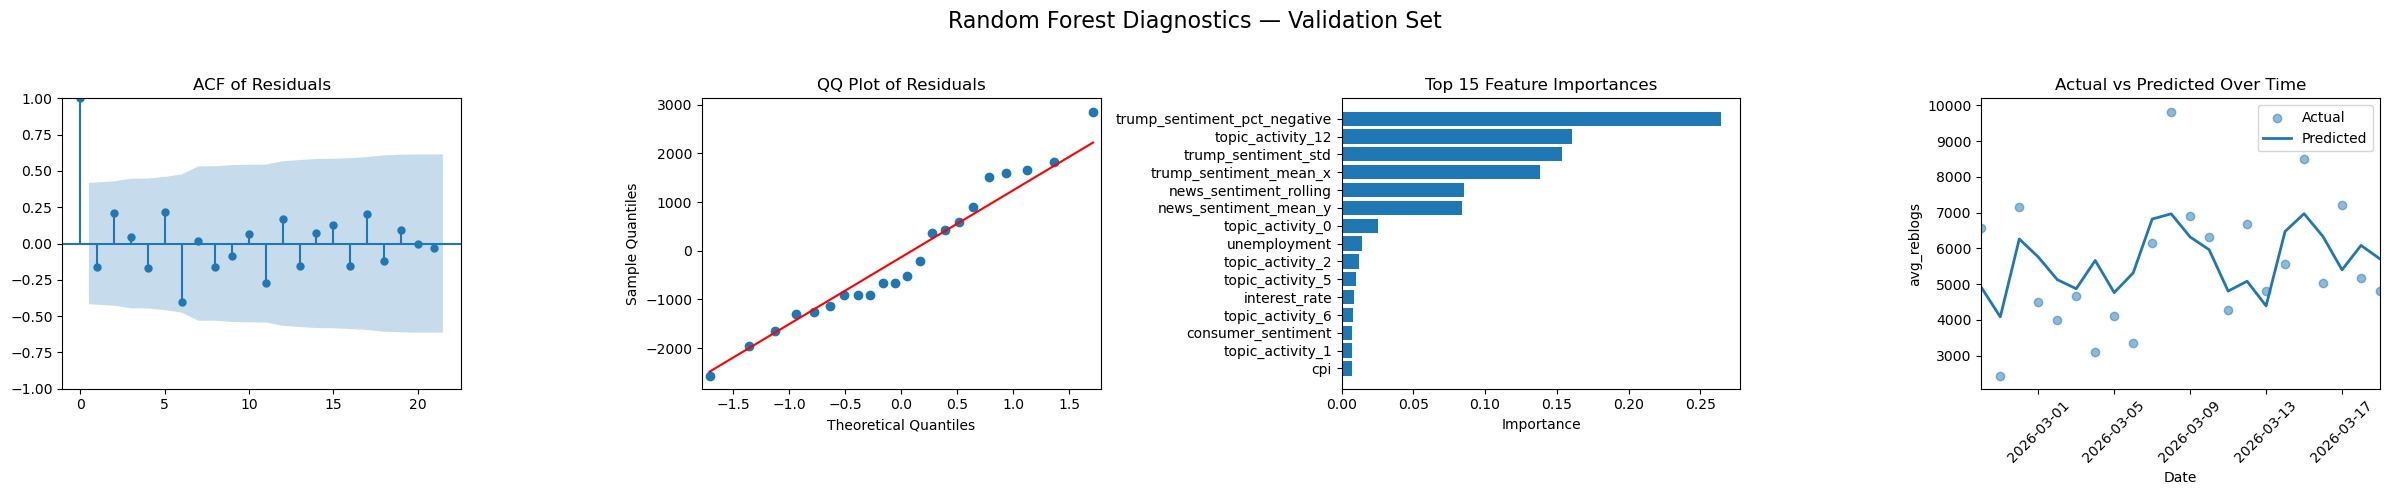

Target: avg_upvotes
RMSE:   5444.735180
MAE:    4343.263227
R2:     0.282166


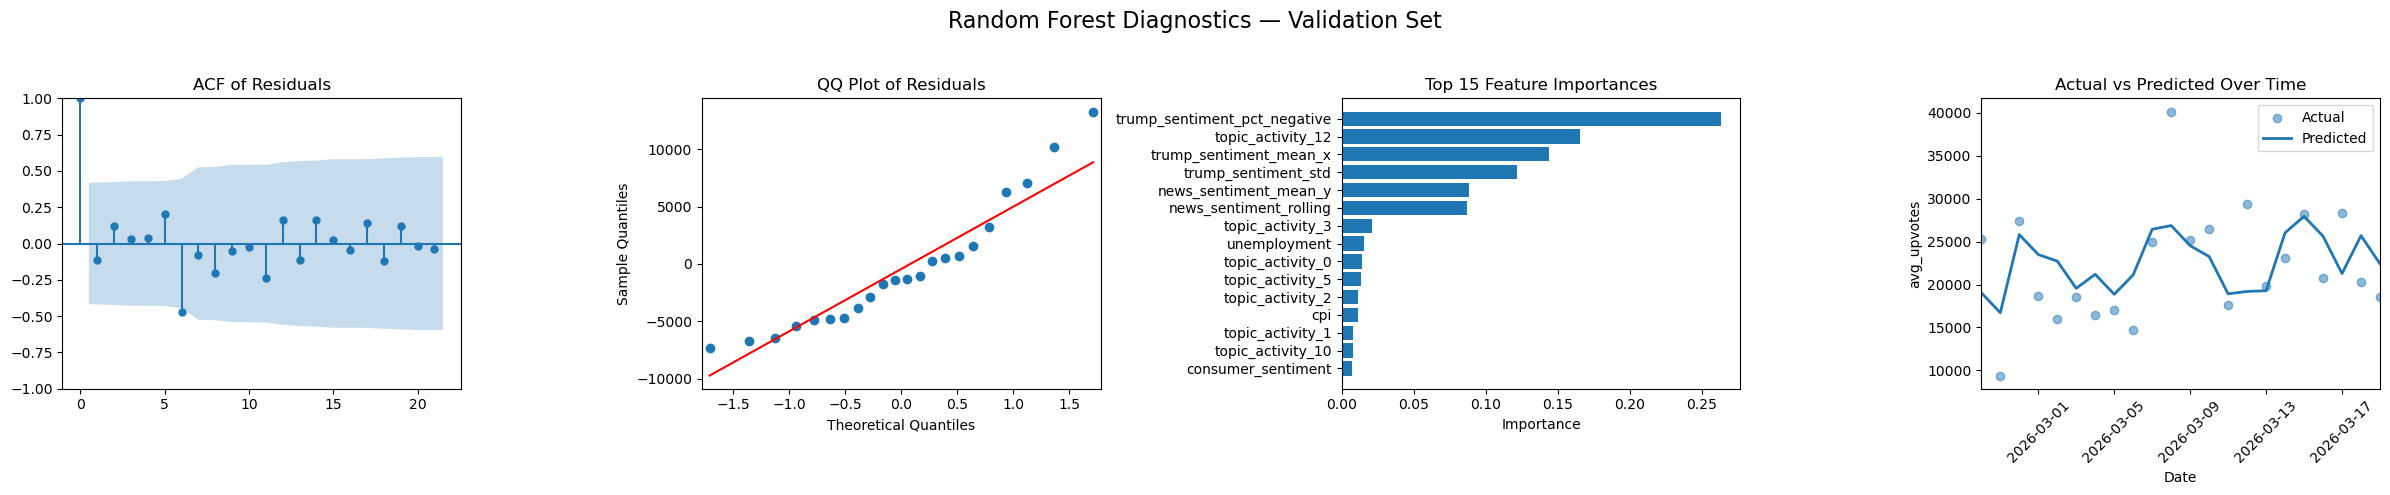

Target: total_upvotes
RMSE:   177921.257758
MAE:    132274.805227
R2:     0.153341


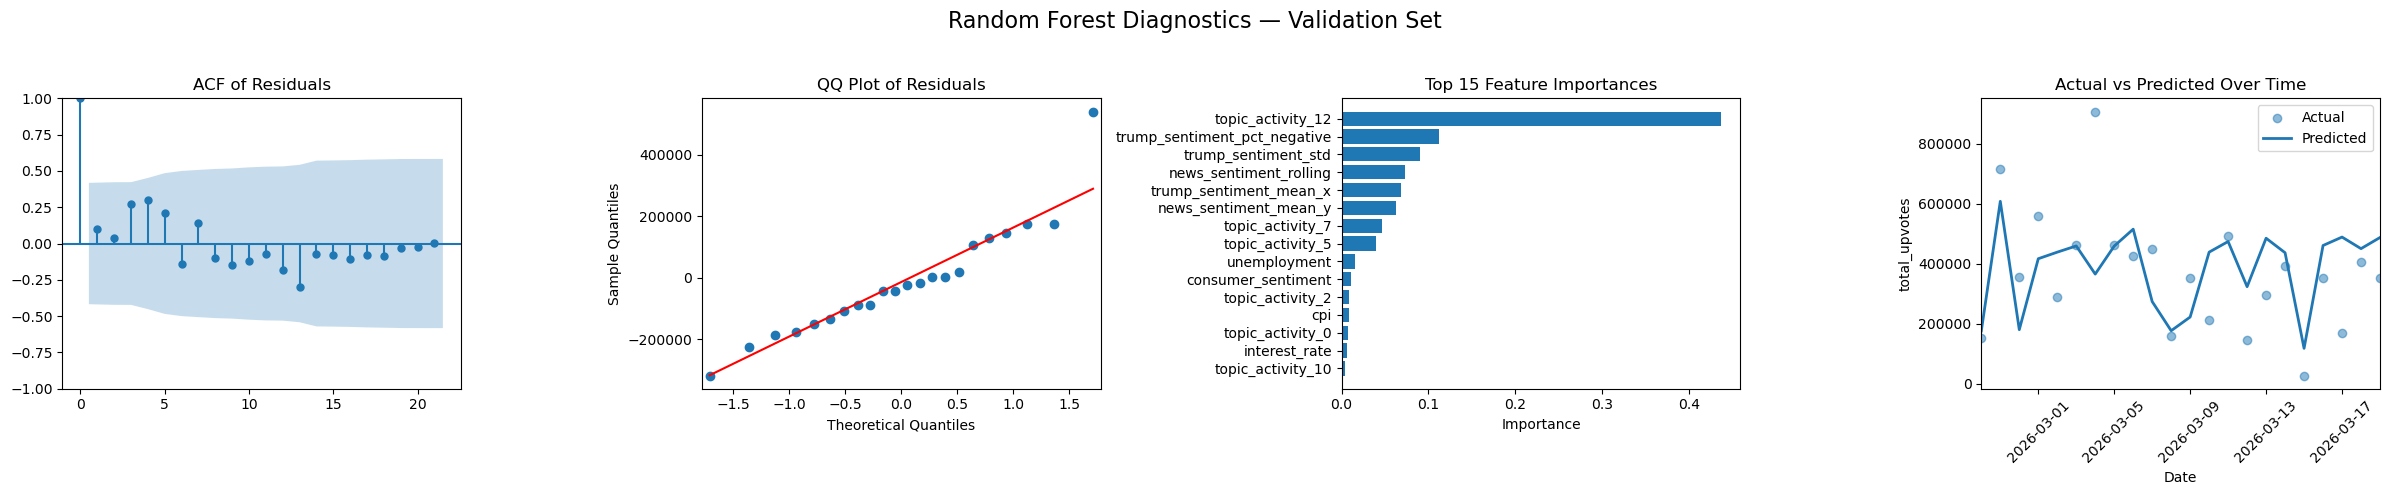

In [25]:
rf_model = results[
    [r["model_name"] for r in results].index("random_forest")
]["model"]

rf_val_diag = utils_ml.diagnose_random_forest(
    model=rf_model,
    X=X_val,
    Y=Y_val,
    time_data=df['date'],
    target_idx=0,
    lags=40,
    title="Random Forest Diagnostics — Validation Set"
)

rf_val_diag = utils_ml.diagnose_random_forest(
    model=rf_model,
    X=X_val,
    Y=Y_val,
    time_data=df['date'],
    target_idx=1,
    lags=40,
    title="Random Forest Diagnostics — Validation Set"
)

rf_val_diag = utils_ml.diagnose_random_forest(
    model=rf_model,
    X=X_val,
    Y=Y_val,
    time_data=df['date'],
    target_idx=2,
    lags=40,
    title="Random Forest Diagnostics — Validation Set"
)

#### 4.2.3 - Hyperparameter turning on validaton set

Hyper parameter turning takes a lot of time, so we have stored the result of our grids search, the code for this gridsearch can be found under appendix_D_modeling/Analysis ML - Trump upvotes (best). 

We made the gridsearch based on rmse (Root Mean Square Error)

In [26]:
best_model = joblib.load("data/random_forest_best.pkl")
grid_results_df = pd.read_pickle("data/random_forest_grid.pkl")
with open("data/random_forest_best_param.json", "r") as f:
    best_params = json.load(f)

print("Loaded model and grid search results")
print(best_params)

Loaded model and grid search results
{'max_depth': 3, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}


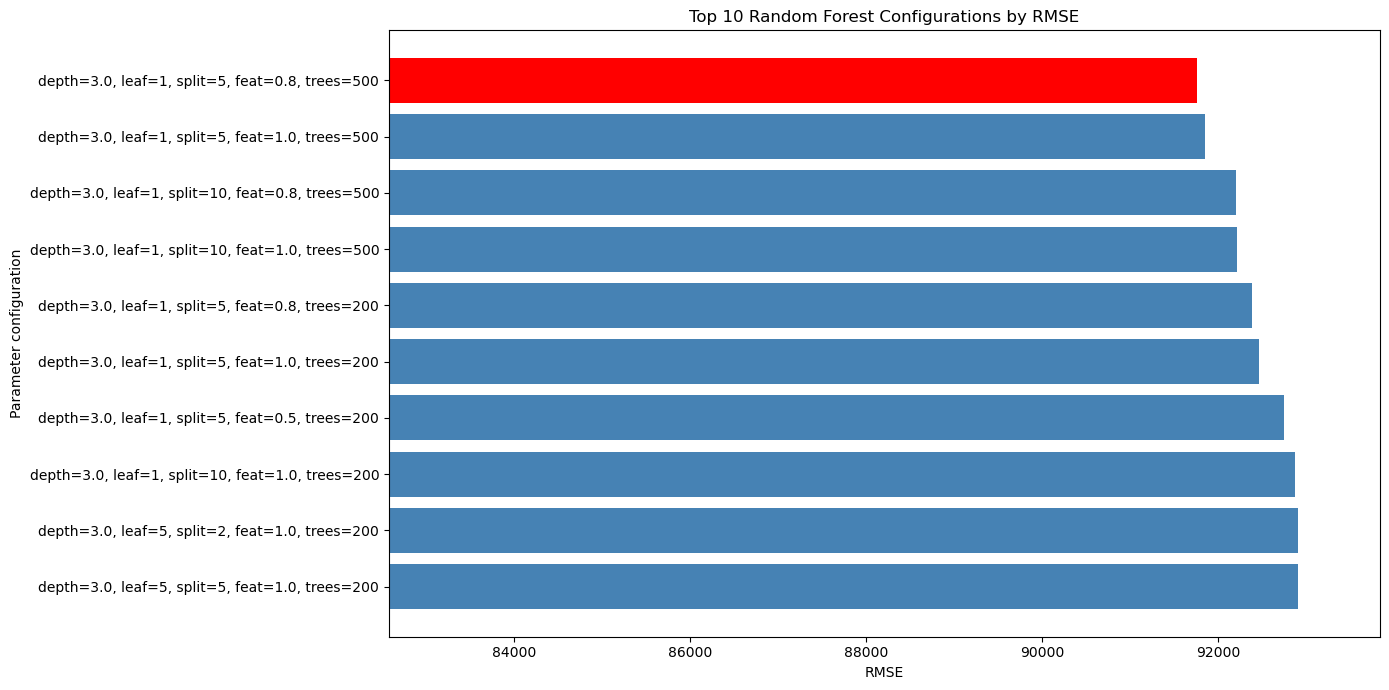

In [27]:
utils_ml.plot_rf_grid_results(grid_results_df, best_params, metric="rmse", top_n=10)

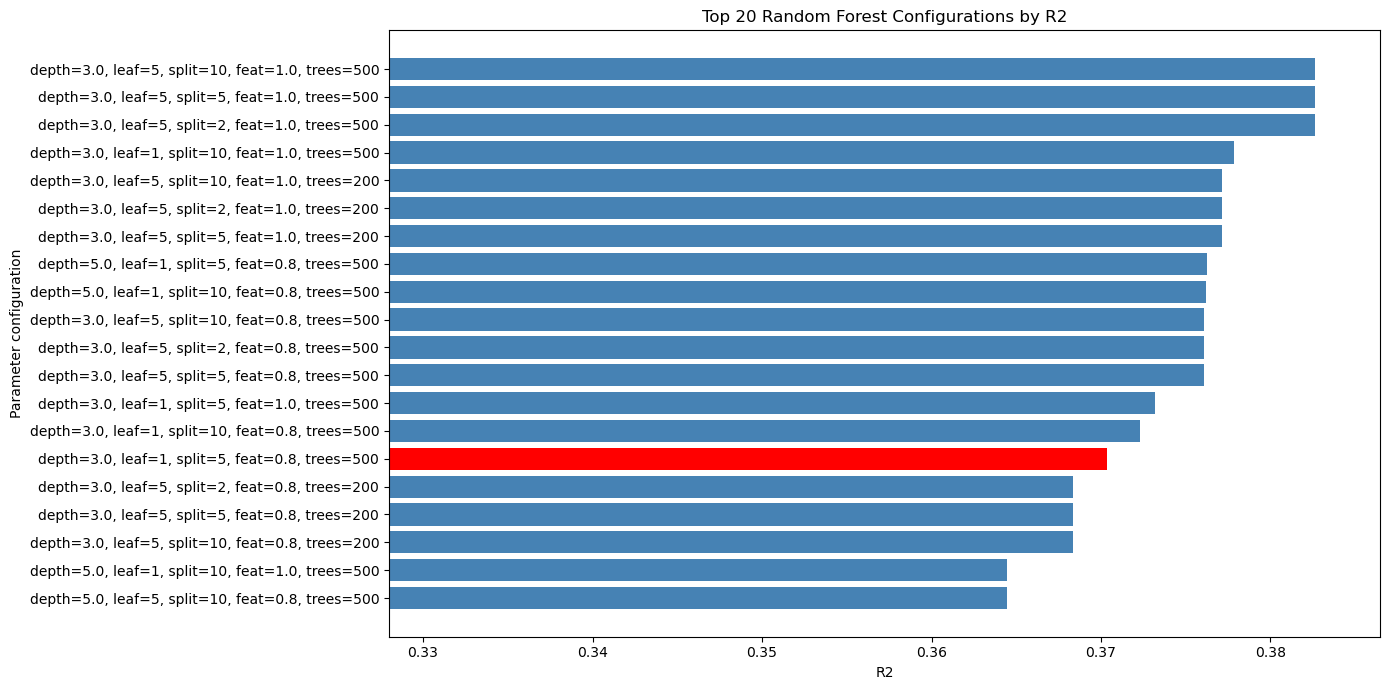

In [29]:
utils_ml.plot_rf_grid_results(grid_results_df, best_params, metric="r2", top_n=20)

We see that the model that got the least error is not the same as the model, which explains most of the variance in the data. This was a desing choice we made when doing grid search, that we dit it to minimize error and not to maximze the explained variance

In [30]:
warnings.filterwarnings("ignore")
df_encoded = utils_ml.encode_for_parallel_plot(grid_results_df)

fig = px.parallel_coordinates(
    df_encoded,
    dimensions=[
        "n_estimators", # Number of trees in the ensemble.
        "max_depth_encoded", # Maximum depth of the trees.
        "min_samples_leaf", # Minimum number of samples required to be at a leaf node.
        "min_samples_split", # Minimum number of samples required to split an internal node.
        "max_features_encoded", # Maximum number of features to consider for best split.
        "rmse"
    ],
    color="rmse",
    color_continuous_scale="Viridis",
    title="Random Forest Hyperparameter Sweep"
)

fig.show()
warnings.filterwarnings("default")

max_depth {'12.0': 0, '3.0': 1, '5.0': 2, '8.0': 3, 'nan': 4}
max_features {'0.5': 0, '0.8': 1, '1.0': 2, 'sqrt': 3}


In [31]:
warnings.filterwarnings("ignore")
df_encoded = utils_ml.encode_for_parallel_plot(grid_results_df)

fig = px.parallel_coordinates(
    df_encoded,
    dimensions=[
        "n_estimators", # Number of trees in the ensemble.
        "max_depth_encoded", # Maximum depth of the trees.
        "min_samples_leaf", # Minimum number of samples required to be at a leaf node.
        "min_samples_split", # Minimum number of samples required to split an internal node.
        "max_features_encoded", # Maximum number of features to consider for best split.
        "r2"
    ],
    color="r2",
    color_continuous_scale="Viridis",
    title="Random Forest Hyperparameter Sweep"
)

fig.show()
warnings.filterwarnings("default")

max_depth {'12.0': 0, '3.0': 1, '5.0': 2, '8.0': 3, 'nan': 4}
max_features {'0.5': 0, '0.8': 1, '1.0': 2, 'sqrt': 3}


r^2 measure how much variance in the target is explained by the model

### 4.3 Testing the model

---
## 5. Explainability and Endogeneity

### 5.1 Explainable AI

*(Describe which explainability methods are applied — e.g. SHAP values, permutation importance, partial dependence plots. Which features drive predictions and in which direction?)*



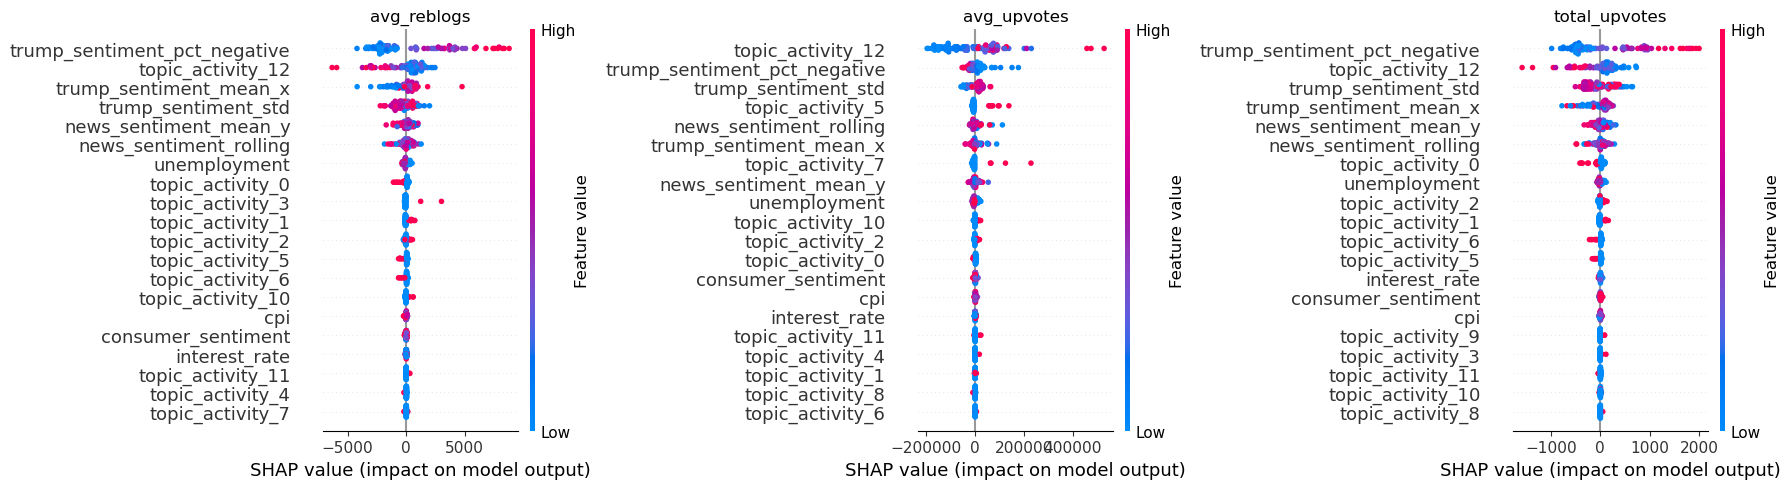

In [ ]:
utils_ml.shap_analysis_side_by_side(
    model=rf_model,
    X=X_train,
    target_names=list(Y_train.columns),
    sample_size=500
)

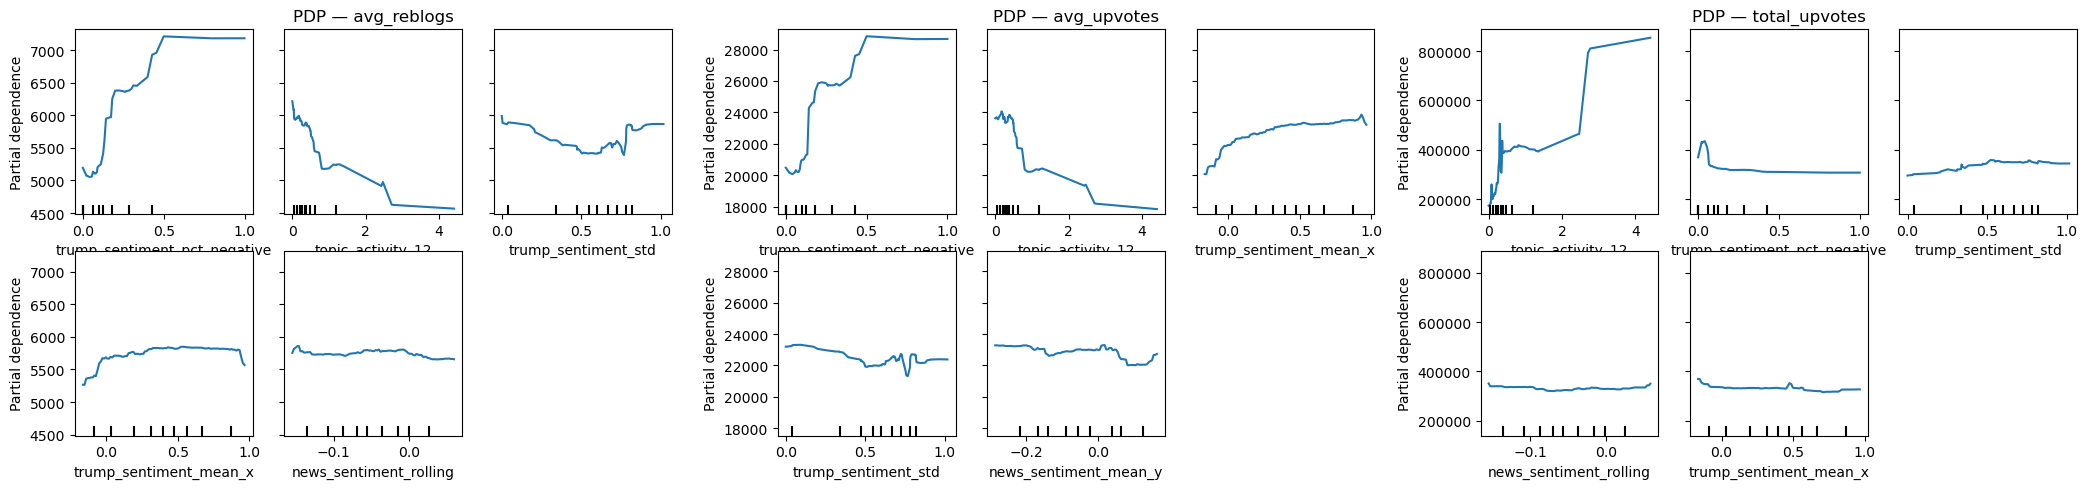

In [ ]:
utils_ml.pdp_analysis_side_by_side(
    model=rf_model,
    X=X_train,
    target_names=list(Y_train.columns),
    top_n=5,
    sample_size=500
)

### 5.2 Endogeneity

A key concern in this analysis is endogeneity — the possibility that the relationship between Trump's posting behaviour and the outcome variable runs in both directions, or that both are driven by a common third factor.

**Reverse causality:** Trump may post more (or more aggressively) in response to market or political developments, rather than causing them. To mitigate this, all NLP and behavioural features are lagged by at least one day so that post content strictly precedes the outcome variable.

**Omitted variable bias:** External shocks — geopolitical events, Fed announcements, earnings releases — may simultaneously affect both Trump's posting behaviour and the outcome. Macro indicators (CPI, Fed Funds Rate, Unemployment, Consumer Sentiment) are included as controls to absorb part of this variation.

*(Describe any additional steps taken — instrumental variables, robustness checks, placebo tests — and discuss remaining limitations.)*

---
## 6. Results

*(Key results — tables, figures. Pull in the most important outputs from the analysis notebooks.)*

---
## 7. Discussion

*(Interpret results, limitations, alternative explanations.)*

---
## 8. Conclusion

*(2–4 sentences answering the research question and pointing to future work.)*

---
## 9. Appendix

### Appendix A — Trump Truth Social data

| Notebook | Contents |
|---|---|
| `appendix_A_trump/01_trump_data.ipynb` | Raw data loading, cleaning, behavioural feature engineering, daily aggregation |
| `appendix_A_trump/02_trump_nlp.ipynb` | Text preprocessing, BERTopic topic modelling, VADER sentiment analysis, NLP feature export |

### Appendix B — News data

| Notebook / Script | Contents |
|---|---|
| `appendix_B_news/` *(XXX)* | *(XXX)* |

### Appendix C — Macro indicators

| Notebook / Script | Contents |
|---|---|
| `appendix_C_macro/` *(XXX)* | *(XXX)* |

### Appendix D — Modelling

| Notebook | Contents |
|---|---|
| `appendix_D_modelling/` *(XXX)* | *(XXX)* |